In [2]:
import pandas as pd 
import numpy as np
import datetime
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

In [3]:
# Read all 5 datasets

bus_line = pd.read_csv('bus_line.csv')
bus_vol = pd.read_csv('bus_vol.csv')
hdb = pd.read_csv('hdb.csv')
mrt = pd.read_csv('mrt.csv')
poi = pd.read_csv('poi.csv')

In [4]:
# Checking number of removed rows

def log_change(df_before, df_after, name):
    removed = len(df_before) - len(df_after)
    print(f"{name}: Removed {removed} rows ({round(removed/len(df_before)*100, 2)}%)")

In [5]:
# Cleaning of Bus Line Dataset

df_before = bus_line.copy()

# Drop "Unnamed: 0" column
bus_line.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Standardize stop_id to string format
bus_line['stop_id'] = bus_line['stop_id'].astype(str)

# Convert time columns to datetime format
time_cols = ['WD_FirstBus','WD_LastBus','SAT_FirstBus','SAT_LastBus','SUN_FirstBus','SUN_LastBus']
for col in time_cols:
    bus_line[col] = pd.to_datetime(bus_line[col], format='%H%M', errors='coerce')

# Remove negative distances
bus_line = bus_line[bus_line['distance'] >= 0]

# Remove duplicates
bus_line = bus_line.drop_duplicates(subset=['line','direction','sequence','stop_id'])

# Adding coordinates information
bus_stops = pd.read_csv('bus_stops.csv')
bus_stops['BusStopCode'] = bus_stops['BusStopCode'].astype(str)
bus_line['stop_id'] = bus_line['stop_id'].astype(str)

bus_stops.rename(columns={
    'BusStopCode': 'stop_id',
    'Latitude': 'lat',
    'Longitude': 'lng'
}, inplace=True)

bus_line = bus_line.merge(
    bus_stops[['stop_id', 'lat', 'lng']],
    on='stop_id',
    how='left'
)

# Remove missing coordinates
bus_line = bus_line.dropna(subset=['lat','lng'])

log_change(df_before, bus_line, "BUS LINE")
bus_line

# Note: Certain rows have NaT in time columns but will be kept as these stops may only operate on certain days of the week

BUS LINE: Removed 51 rows (0.19%)


,line,operator,direction,sequence,stop_id,distance,WD_FirstBus,WD_LastBus,SAT_FirstBus,SAT_LastBus,SUN_FirstBus,SUN_LastBus,lat,lng
0,10,SBST,1,1,75009,0.0,1900-01-01 05:00:00,1900-01-01 23:00:00,1900-01-01 05:00:00,1900-01-01 23:00:00,1900-01-01 05:00:00,1900-01-01 23:00:00,1.354076,103.943391
1,10,SBST,1,2,76059,0.6,1900-01-01 05:02:00,1900-01-01 23:02:00,1900-01-01 05:02:00,1900-01-01 23:02:00,1900-01-01 05:02:00,1900-01-01 23:02:00,1.352962,103.941652
2,10,SBST,1,3,76069,1.1,1900-01-01 05:04:00,1900-01-01 23:04:00,1900-01-01 05:04:00,1900-01-01 23:04:00,1900-01-01 05:03:00,1900-01-01 23:04:00,1.348753,103.942086
3,10,SBST,1,4,96289,2.3,1900-01-01 05:08:00,1900-01-01 23:08:00,1900-01-01 05:08:00,1900-01-01 23:09:00,1900-01-01 05:07:00,1900-01-01 23:08:00,1.340055,103.948381
4,10,SBST,1,5,96109,2.7,1900-01-01 05:09:00,1900-01-01 23:10:00,1900-01-01 05:09:00,1900-01-01 23:11:00,1900-01-01 05:08:00,1900-01-01 23:09:00,1.337371,103.950673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26262,NR8,SMRT,1,57,43839,23.1,NaT,NaT,1900-01-01 02:08:00,1900-01-01 02:54:00,NaT,NaT,1.365273,103.748250
26263,NR8,SMRT,1,58,43649,23.4,NaT,NaT,1900-01-01 02:09:00,1900-01-01 02:55:00,NaT,NaT,1.365458,103.750602
26264,NR8,SMRT,1,59,43589,23.9,NaT,NaT,1900-01-01 03:00:00,1900-01-01 02:56:00,NaT,NaT,1.362273,103.751532
26265,NR8,SMRT,1,60,43579,24.3,NaT,NaT,1900-01-01 03:01:00,1900-01-01 02:57:00,NaT,NaT,1.359117,103.751668


In [6]:
# Cleaning of Bus Volume Dataset

df_before = bus_vol.copy()

# Drop "Unnamed: 0" column
bus_vol.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Standardize stop_id to string format
bus_vol['stop_id'] = bus_vol['stop_id'].astype(str)

# Remove negative passenger counts
bus_vol = bus_vol[(bus_vol['in'] >= 0) & (bus_vol['out'] >= 0)]

# Add total volume column
bus_vol['total_volume'] = bus_vol['in'] + bus_vol['out']

# Remove duplicates
bus_vol = bus_vol.drop_duplicates(subset=['stop_id','hour','day','month'])

# Adding coordinates information
bus_stops = pd.read_csv('bus_stops.csv')
bus_stops['BusStopCode'] = bus_stops['BusStopCode'].astype(str)
bus_vol['stop_id'] = bus_vol['stop_id'].astype(str)

bus_stops.rename(columns={
    'BusStopCode': 'stop_id',
    'Latitude': 'lat',
    'Longitude': 'lng'
}, inplace=True)

bus_vol = bus_vol.merge(
    bus_stops[['stop_id', 'lat', 'lng']],
    on='stop_id',
    how='left'
)

# Remove missing coordinates
bus_vol = bus_vol.dropna(subset=['lat','lng'])

log_change(df_before, bus_vol, "BUS VOL")
bus_vol

BUS VOL: Removed 7331 rows (1.26%)


,day,hour,stop_id,in,out,month,total_volume,lat,lng
0,WD,17,45379,444,327,202107,771,1.394694,103.751873
1,H,17,45379,133,91,202107,224,1.394694,103.751873
2,WD,13,80051,1998,2185,202107,4183,1.312515,103.873262
3,H,13,80051,1021,1089,202107,2110,1.312515,103.873262
4,H,13,5319,5,29,202107,34,1.284497,103.849087
...,...,...,...,...,...,...,...,...,...
580967,H,20,43381,36,192,202109,228,1.346966,103.747660
580968,H,7,51011,232,254,202109,486,1.327842,103.840611
580969,WD,7,51011,1632,1635,202109,3267,1.327842,103.840611
580970,H,6,13139,30,138,202109,168,1.295043,103.832055


In [7]:
# Cleaning of HDB dataset

df_before = hdb.copy()

# Drop "Unnamed: 0" column
hdb.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Standardize text
hdb['street'] = hdb['street'].str.upper()
hdb['building'] = hdb['building'].str.upper()

# Remove missing coordinates
hdb = hdb.dropna(subset=['lat','lng'])

# Remove negative dwelling values
hdb = hdb[hdb['total_dwelling_units'] > 0]

# Remove duplicates
hdb = hdb.drop_duplicates(subset=['blk_no','street'])

log_change(df_before, hdb, "HDB")
hdb

HDB: Removed 2261 rows (18.17%)


,blk_no,street,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,...,building,addr,postal,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,1,BEACH RD,16,1970,Y,Y,N,N,N,N,...,RAFFLES HOTEL,1 BEACH ROAD RAFFLES HOTEL SINGAPORE 189673,189673,2.0,CITY HALL,DTSZ02,DOWNTOWN CORE,DT,CENTRAL REGION,CR
1,1,BEDOK STH AVE 1,14,1975,Y,N,N,Y,N,N,...,NIL,1 BEDOK SOUTH AVENUE 1 SINGAPORE 460001,460001,6.0,BEDOK SOUTH,BDSZ06,BEDOK,BD,EAST REGION,ER
3,1,CHAI CHEE RD,15,1982,Y,N,N,N,N,N,...,PING YI GARDENS,1 CHAI CHEE ROAD PING YI GARDENS SINGAPORE 461001,461001,3.0,KEMBANGAN,BDSZ03,BEDOK,BD,EAST REGION,ER
4,1,CHANGI VILLAGE RD,4,1975,Y,Y,N,N,N,N,...,OCBC CHANGI VILLAGE ROAD - 7 ELEVEN,1 CHANGI VILLAGE ROAD OCBC CHANGI VILLAGE ROAD...,500001,1.0,CHANGI POINT,CHSZ01,CHANGI,CH,EAST REGION,ER
5,1,DELTA AVE,25,1982,Y,N,N,N,N,N,...,NIL,1 DELTA AVENUE SINGAPORE 160001,160001,9.0,BUKIT HO SWEE,BMSZ09,BUKIT MERAH,BM,CENTRAL REGION,CR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12434,997C,BUANGKOK CRES,16,2017,Y,N,N,N,N,N,...,BUANGKOK EDGEVIEW,997C BUANGKOK CRESCENT BUANGKOK EDGEVIEW SINGA...,534997,5.0,TRAFALGAR,HGSZ05,HOUGANG,HG,NORTH-EAST REGION,NER
12437,998A,BUANGKOK CRES,18,2018,Y,N,N,N,N,N,...,BUANGKOK PARKVISTA,998A BUANGKOK CRESCENT BUANGKOK PARKVISTA SING...,531998,5.0,TRAFALGAR,HGSZ05,HOUGANG,HG,NORTH-EAST REGION,NER
12438,998B,BUANGKOK CRES,17,2018,Y,N,N,N,N,N,...,BUANGKOK PARKVISTA,998B BUANGKOK CRESCENT BUANGKOK PARKVISTA SING...,532998,5.0,TRAFALGAR,HGSZ05,HOUGANG,HG,NORTH-EAST REGION,NER
12440,999A,BUANGKOK CRES,18,2018,Y,N,N,N,N,N,...,BUANGKOK PARKVISTA,999A BUANGKOK CRESCENT BUANGKOK PARKVISTA SING...,531999,5.0,TRAFALGAR,HGSZ05,HOUGANG,HG,NORTH-EAST REGION,NER


In [8]:
# Cleaning of mrt dataset

df_before = mrt.copy()

# Drop "Unnamed: 0" column
mrt.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Standardize text
mrt['name'] = mrt['name'].str.upper()

# Remove missing coordinates
mrt = mrt.dropna(subset=['lat','lng'])

# Remove duplicates
mrt = mrt.drop_duplicates(subset=['stop_id'])

log_change(df_before, mrt, "MRT")
mrt

MRT: Removed 63 rows (25.51%)


,name,stop_id,line,no,lng,lat,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,EUNOS MRT STATION,EW7,EW,49,103.903252,1.319779,5,GEYLANG EAST,GLSZ05,GEYLANG,GL,CENTRAL REGION,CR
1,CHINESE GARDEN MRT STATION,EW25,EW,33,103.732597,1.342353,4,LAKESIDE (LEISURE),JESZ04,JURONG EAST,JE,WEST REGION,WR
2,KHATIB MRT STATION,NS14,NS,75,103.832980,1.417383,8,KHATIB,YSSZ08,YISHUN,YS,NORTH REGION,NR
3,KRANJI MRT STATION,NS7,NS,78,103.762165,1.425178,2,TURF CLUB,SKSZ02,SUNGEI KADUT,SK,NORTH REGION,NR
4,REDHILL MRT STATION,EW18,EW,117,103.816817,1.289563,3,REDHILL,BMSZ03,BUKIT MERAH,BM,CENTRAL REGION,CR
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,HARBOURFRONT MRT STATION,NE1 / CC29,NE,59,103.821443,1.265473,1,MARITIME SQUARE,BMSZ01,BUKIT MERAH,BM,CENTRAL REGION,CR
183,BAYFRONT MRT STATION,DT16 / CE1,DT,6,103.859080,1.281874,12,BAYFRONT SUBZONE,DTSZ12,DOWNTOWN CORE,DT,CENTRAL REGION,CR
185,RAFFLES PLACE MRT STATION,EW14 / NS26,EW,115,103.851462,1.284126,5,RAFFLES PLACE,DTSZ05,DOWNTOWN CORE,DT,CENTRAL REGION,CR
187,PUNGGOL LRT STATION,PTC,PE,111,103.902412,1.405195,2,PUNGGOL TOWN CENTRE,PGSZ02,PUNGGOL,PG,NORTH-EAST REGION,NER


In [9]:
# Cleaning of poi dataset 

df_before = poi.copy()

# Drop "Unnamed: 0" column
poi.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Dropping other not so helpful columns
poi.drop(columns=['price_level', 'brand', 'formatted_address', 'global_code'], inplace=True)

# Drop rows with small missing location values (Just 2 rows)
poi = poi.dropna(subset=[
    'PLN_AREA_C', 'SUBZONE_NO', 'SUBZONE_N',
    'SUBZONE_C', 'PLN_AREA_N', 'planning_area'
])

# Remove duplicates 
poi = poi.drop_duplicates(subset=['place_id'])

# Remove missing values
poi = poi.dropna(subset=['lat', 'lng', 'rating', 'user_ratings_total'])

# Remove invalid values
poi = poi[poi['rating'].between(0, 5)]
poi = poi[poi['user_ratings_total'] >= 0]

# Define category groups 
category_groups = {

    'food_beverage': [
        'food', 'restaurant', 'cafe', 'bakery', 'meal_takeaway',
        'meal_delivery', 'bar', 'liquor_store'
    ],

    'healthcare': [
        'health', 'hospital', 'doctor', 'dentist', 'pharmacy',
        'physiotherapist', 'drugstore', 'veterinary_care'
    ],

    'education': [
        'school', 'primary_school', 'secondary_school',
        'university', 'library'
    ],

    'retail_commerce': [
        'store', 'shopping_mall', 'department_store', 'clothing_store',
        'shoe_store', 'jewelry_store', 'home_goods_store',
        'furniture_store', 'electronics_store', 'book_store',
        'supermarket', 'grocery_or_supermarket', 'convenience_store',
        'pet_store', 'florist', 'beauty_salon', 'hair_care',
        'spa', 'laundry', 'bicycle_store', 'hardware_store'
    ],

    'transport': [
        'transit_station', 'bus_station', 'subway_station',
        'train_station', 'light_rail_station', 'taxi_stand',
        'airport', 'parking', 'gas_station', 'car_rental',
        'car_repair', 'car_wash', 'car_dealer'
    ],

    'finance_business': [
        'finance', 'bank', 'atm', 'insurance_agency',
        'accounting', 'real_estate_agency', 'lawyer',
        'travel_agency'
    ],

    'religious_civic': [
        'place_of_worship', 'church', 'mosque', 'hindu_temple',
        'synagogue', 'embassy', 'local_government_office',
        'city_hall', 'courthouse', 'police', 'fire_station',
        'post_office', 'funeral_home', 'cemetery'
    ],

    'recreation_entertainment': [
        'tourist_attraction', 'park', 'gym', 'museum',
        'movie_theater', 'night_club', 'amusement_park',
        'bowling_alley', 'aquarium', 'zoo', 'stadium',
        'art_gallery', 'campground', 'casino', 'natural_feature'
    ],

    'lodging_residential': [
        'lodging'
    ],

    'services_contractors': [
        'general_contractor', 'electrician', 'plumber',
        'locksmith', 'roofing_contractor', 'moving_company',
        'storage', 'painter'
    ],

    'public_place_general': [
        'establishment', 'point_of_interest', 'premise', 'subpremise'
    ]
}

# Create grouped category column
for group, cols in category_groups.items():
    existing_cols = [c for c in cols if c in poi.columns]
    poi[group] = poi[existing_cols].any(axis=1)

# Combined label
group_cols = list(category_groups.keys())

poi['poi_group'] = poi[group_cols].apply(
    lambda row: ','.join(row.index[row].tolist()) if row.any() else 'other',
    axis=1
)

log_change(df_before, poi, "POI")
poi

POI: Removed 3 rows (0.03%)


,place_id,name,lat,lng,rating,user_ratings_total,compound_code,planning_area,establishment,point_of_interest,...,education,retail_commerce,transport,finance_business,religious_civic,recreation_entertainment,lodging_residential,services_contractors,public_place_general,poi_group
0,ChIJ01fgzLUe2jERxlhvImcbZ7g,Quayside Isle,1.247681,103.842072,4.3,568.0,6RXR+3R Singapore,Southern Islands,True,True,...,False,True,False,False,False,False,False,False,True,"retail_commerce,public_place_general"
1,ChIJ1S4qfY8Q2jERgb68gskzUbo,Sime Darby Centre,1.336644,103.783597,3.7,437.0,8QPM+MC Singapore,Bukit Timah,True,True,...,False,True,False,False,False,False,False,False,True,"retail_commerce,public_place_general"
2,ChIJ1ZAIkrwZ2jERxtZGC1JnrHM,PoMo,1.300192,103.849220,3.8,1285.0,8R2X+3M Singapore,Rochor,True,True,...,False,True,False,False,False,False,False,False,True,"retail_commerce,public_place_general"
3,ChIJ1ZYJOiAZ2jER1mvQqHstQII,LR boulangerie,1.293178,103.827194,4.3,12.0,7RVG+7V Singapore,Tanglin,True,True,...,False,True,False,False,False,False,False,False,True,"food_beverage,retail_commerce,public_place_gen..."
4,ChIJ2Y1DYBI92jERlFUKKSznJrY,Tampines Hub,1.353108,103.940361,4.6,227.0,9W3R+64 Singapore,Tampines,True,True,...,False,True,False,False,False,False,False,False,True,"retail_commerce,public_place_general"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8667,ChIJic0FbG4T2jERlg__g9KNSUU,Old Chang Kee (Head Office),1.450192,103.805305,4.3,25.0,FR24+34 Singapore,Sembawang,True,True,...,False,False,False,False,False,False,False,False,True,"food_beverage,public_place_general"
8668,ChIJ7cjSMX0T2jERGYqGQog7A2E,Old Chang Kee @ Sun Plaza,1.448144,103.819983,3.4,10.0,CRX9+7X Singapore,Sembawang,True,True,...,False,False,False,False,False,False,False,False,True,"food_beverage,public_place_general"
8669,ChIJxXwRE24T2jERDGyVjkkHTTs,Old Chang Kee Bldg,1.449830,103.805229,4.0,2.0,CRX4+W3 Singapore,Sembawang,True,True,...,False,False,True,False,False,False,False,False,True,"transport,public_place_general"
8670,ChIJmQOMh1AT2jERs_1tteD7eTg,Old Chang Kee Coldstore,1.468055,103.812869,0.0,0.0,FR97+64 Singapore,Sembawang,True,True,...,False,True,False,False,False,False,False,False,True,"food_beverage,retail_commerce,public_place_gen..."


In [10]:
def validate_dataset(df, name):
    print(f"\n===== {name.upper()} VALIDATION =====")
    
    print("Shape:", df.shape)
    
    print("\nMissing values:")
    print(df.isnull().sum().sort_values(ascending=False))
    
    print("\nDuplicate rows:", df.duplicated().sum())
    
    print("\nData types:")
    print(df.dtypes.value_counts())

In [11]:
validate_dataset(bus_line, "bus_line")
validate_dataset(bus_vol, "bus_vol")
validate_dataset(bus_vol, "bus_vol")
validate_dataset(hdb, "hdb")
validate_dataset(poi, "poi")


===== BUS_LINE VALIDATION =====
Shape: (26266, 14)

Missing values:
SUN_LastBus     7549
SAT_LastBus     6262
SUN_FirstBus    5174
WD_LastBus      4152
SAT_FirstBus    4028
WD_FirstBus     1822
line               0
operator           0
direction          0
sequence           0
stop_id            0
distance           0
lat                0
lng                0
dtype: int64

Duplicate rows: 0

Data types:
datetime64[ns]    6
object            3
float64           3
int64             2
Name: count, dtype: int64

===== BUS_VOL VALIDATION =====
Shape: (573641, 9)

Missing values:
day             0
hour            0
stop_id         0
in              0
out             0
month           0
total_volume    0
lat             0
lng             0
dtype: int64

Duplicate rows: 0

Data types:
int64      5
object     2
float64    2
Name: count, dtype: int64

===== BUS_VOL VALIDATION =====
Shape: (573641, 9)

Missing values:
day             0
hour            0
stop_id         0
in              0
out   

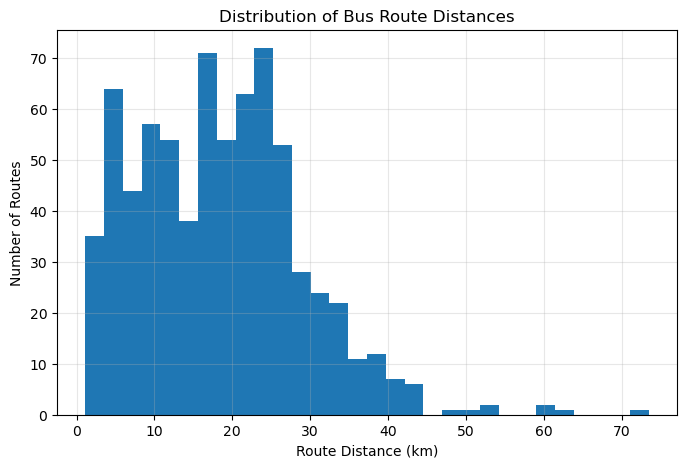

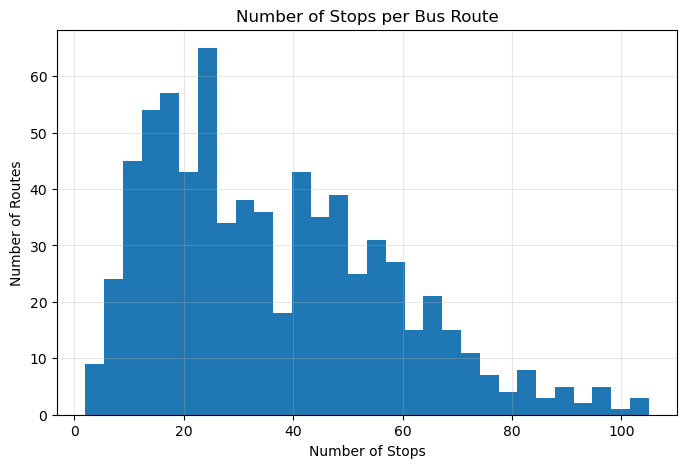

In [12]:
# Bus line EDA

# Route distances
route_dist = bus_line.groupby(['line','direction'])['distance'].max()

plt.figure(figsize=(8,5))
plt.hist(route_dist, bins=30)

plt.title("Distribution of Bus Route Distances")
plt.xlabel("Route Distance (km)")
plt.ylabel("Number of Routes")
plt.grid(alpha=0.3)
plt.show()

# Number of stops per route
stops = bus_line.groupby(['line','direction'])['stop_id'].count()

plt.figure(figsize=(8,5))
plt.hist(stops, bins=30)

plt.title("Number of Stops per Bus Route")
plt.xlabel("Number of Stops")
plt.ylabel("Number of Routes")

plt.grid(alpha=0.3)
plt.show()

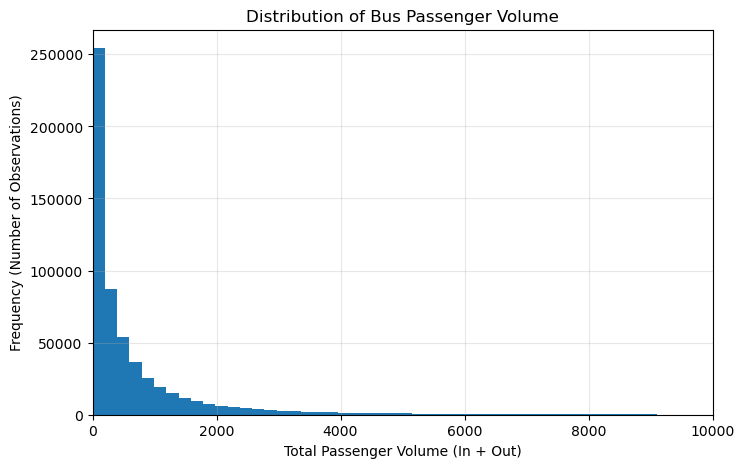

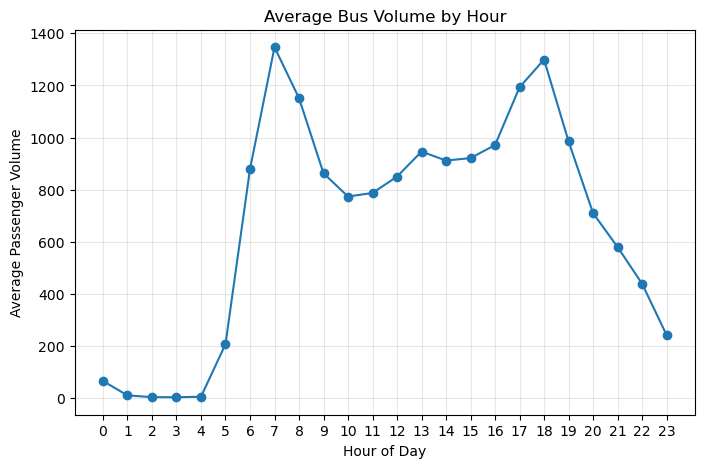

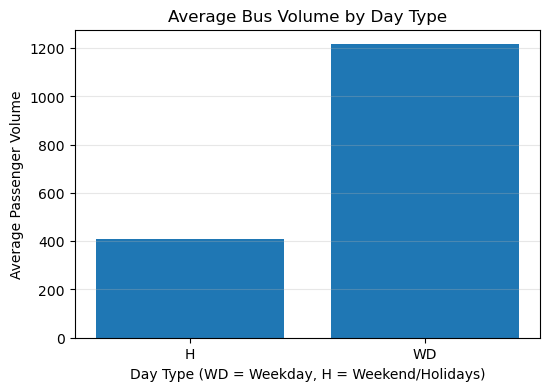

In [13]:
# Bus volume EDA

# Total passenger volume
plt.figure(figsize=(8,5))
plt.hist(bus_vol['total_volume'], bins=1000)
plt.xlim(0, 10000)

plt.title("Distribution of Bus Passenger Volume")
plt.xlabel("Total Passenger Volume (In + Out)")
plt.ylabel("Frequency (Number of Observations)")

plt.grid(alpha=0.3)
plt.show()

# Hourly Trend
hourly = bus_vol.groupby('hour')['total_volume'].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly.index, hourly.values, marker='o')

plt.title("Average Bus Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Passenger Volume")

plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.show()

# Weekday vs Weekend
day_avg = bus_vol.groupby('day')['total_volume'].mean()

plt.figure(figsize=(6,4))
plt.bar(day_avg.index, day_avg.values)

plt.title("Average Bus Volume by Day Type")
plt.xlabel("Day Type (WD = Weekday, H = Weekend/Holidays)")
plt.ylabel("Average Passenger Volume")

plt.grid(axis='y', alpha=0.3)
plt.show()



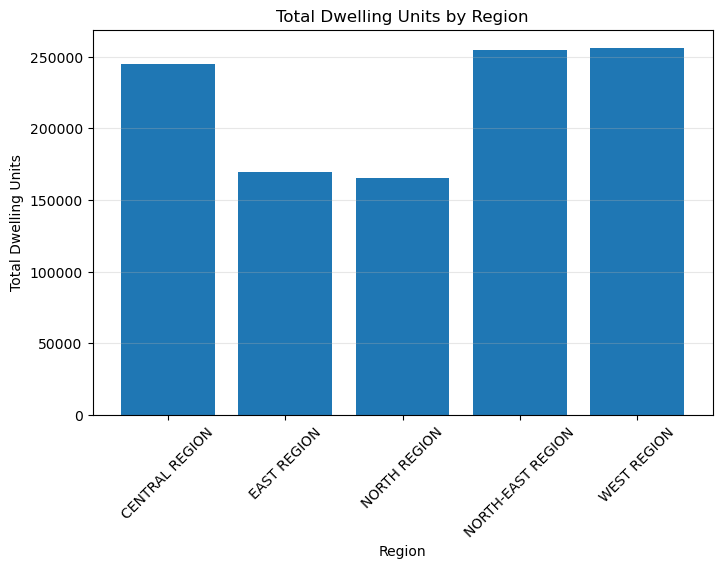

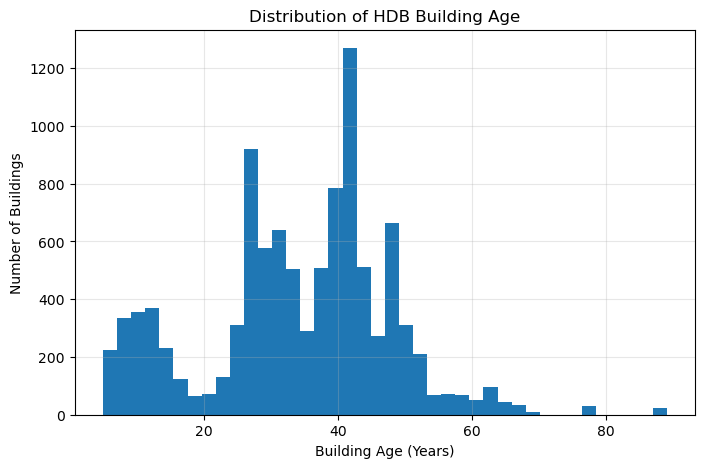

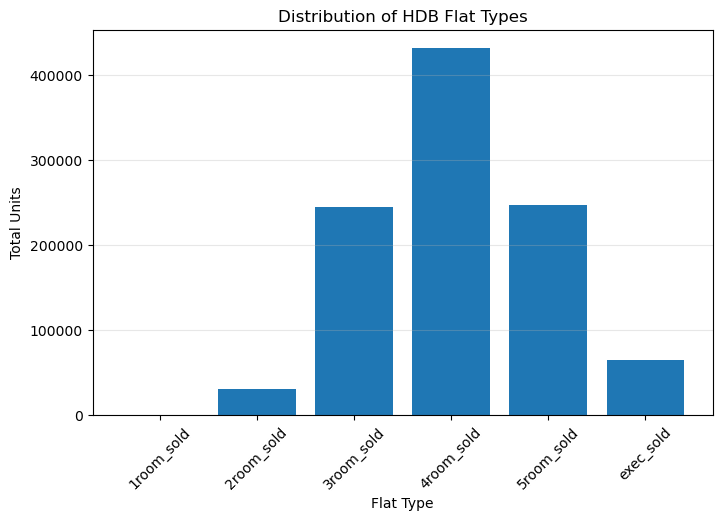

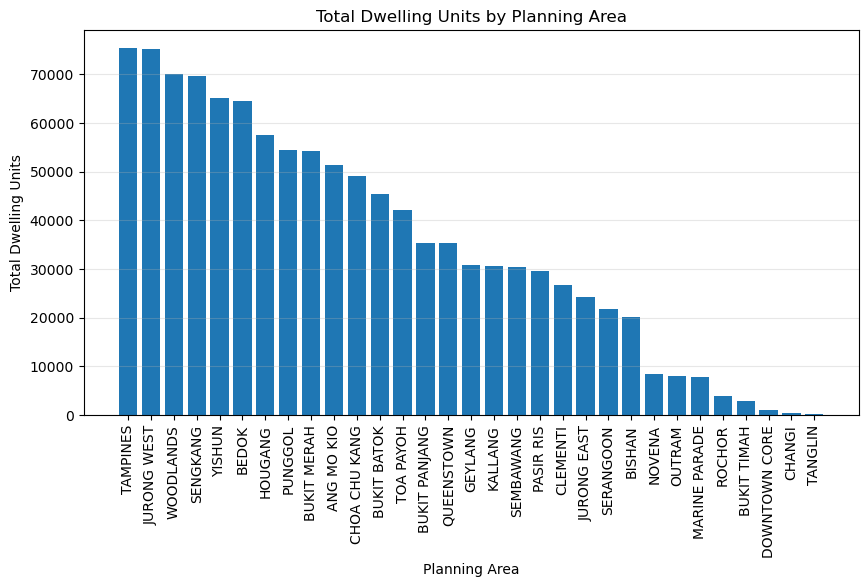

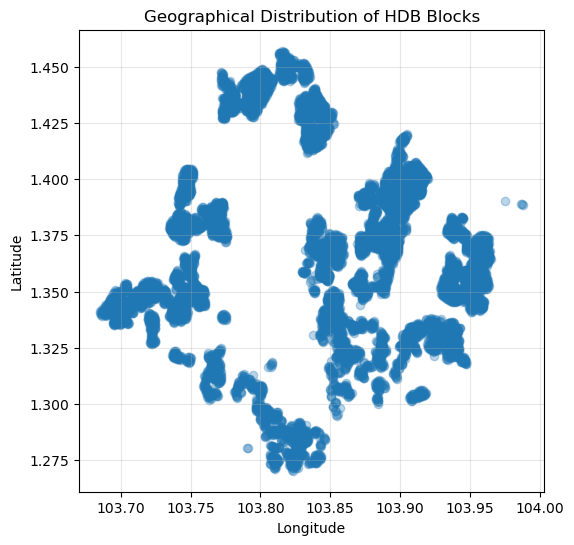

In [14]:
# HDB EDA

# Region Comparison
region_units = hdb.groupby('REGION_N')['total_dwelling_units'].sum()

plt.figure(figsize=(8,5))
plt.bar(region_units.index, region_units.values)

plt.title("Total Dwelling Units by Region")
plt.xlabel("Region")
plt.ylabel("Total Dwelling Units")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Age Comparison
current_year = datetime.datetime.now().year
hdb['building_age'] = current_year - hdb['year_completed']

plt.figure(figsize=(8,5))
plt.hist(hdb['building_age'], bins=40)

plt.title("Distribution of HDB Building Age")
plt.xlabel("Building Age (Years)")
plt.ylabel("Number of Buildings")

plt.grid(alpha=0.3)
plt.show()

# Room Type Composition
room_cols = [
    '1room_sold','2room_sold','3room_sold',
    '4room_sold','5room_sold','exec_sold'
]

room_totals = hdb[room_cols].sum()

plt.figure(figsize=(8,5))
plt.bar(room_totals.index, room_totals.values)

plt.title("Distribution of HDB Flat Types")
plt.xlabel("Flat Type")
plt.ylabel("Total Units")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Density by planning area
area_density = hdb.groupby('PLN_AREA_N')['total_dwelling_units'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(area_density.index, area_density.values)

plt.title("Total Dwelling Units by Planning Area")
plt.xlabel("Planning Area")
plt.ylabel("Total Dwelling Units")

plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Spatial Distribution
plt.figure(figsize=(6,6))
plt.scatter(hdb['lng'], hdb['lat'], alpha=0.3)

plt.title("Geographical Distribution of HDB Blocks")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.3)
plt.show()

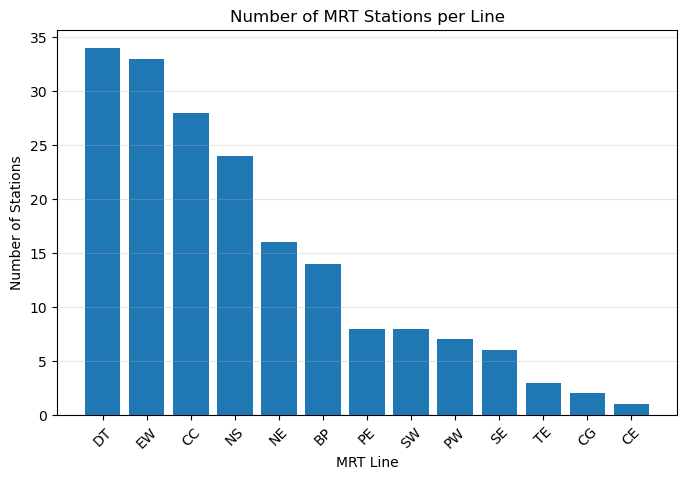

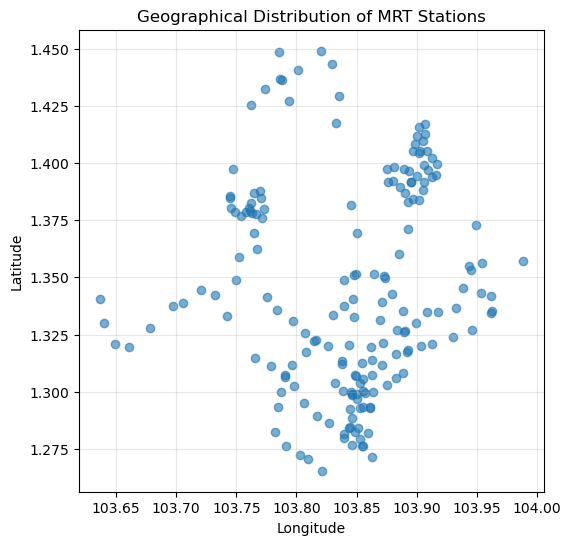

In [15]:
# MRT EDA

# Number of stations per line
line_counts = mrt['line'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(line_counts.index, line_counts.values)

plt.title("Number of MRT Stations per Line")
plt.xlabel("MRT Line")
plt.ylabel("Number of Stations")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Geographical distribution of MRT Stations
plt.figure(figsize=(6,6))
plt.scatter(mrt['lng'], mrt['lat'], alpha=0.6)

plt.title("Geographical Distribution of MRT Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.3)
plt.show()

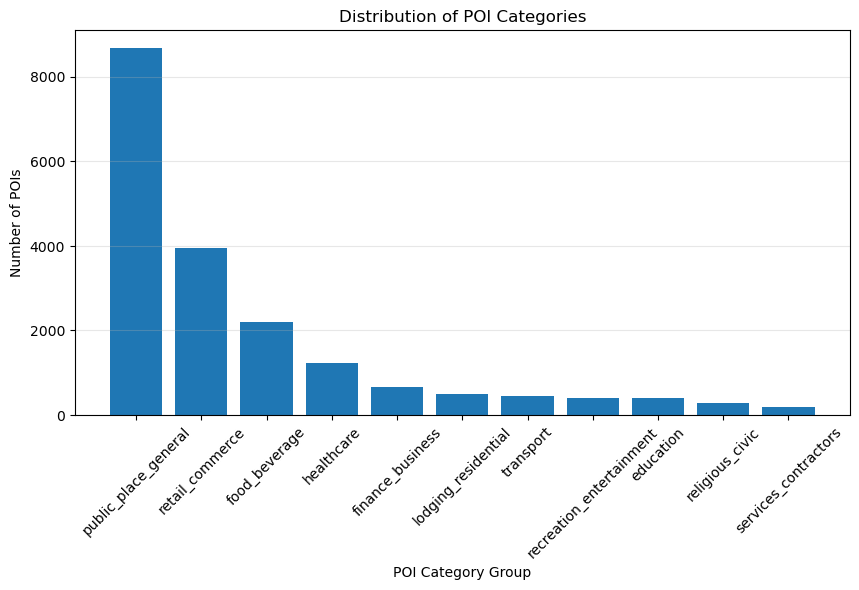

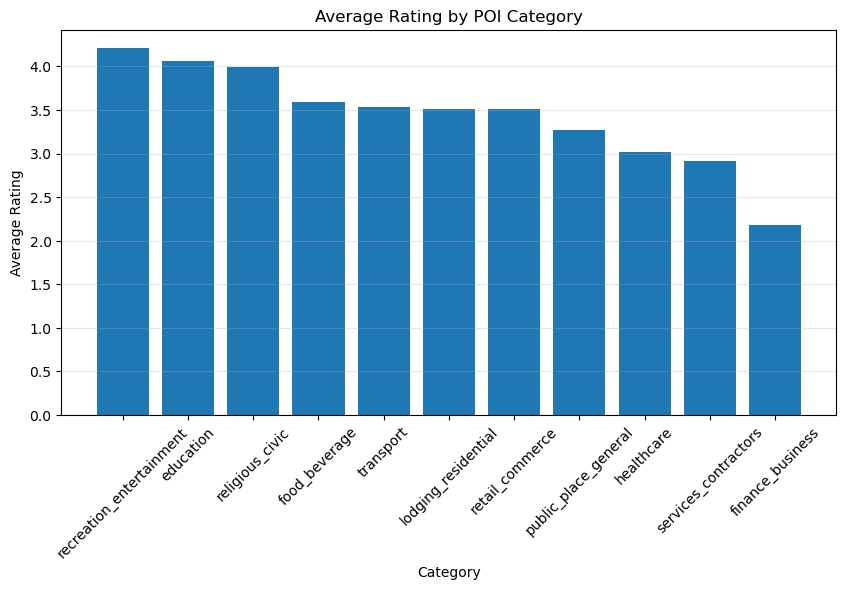

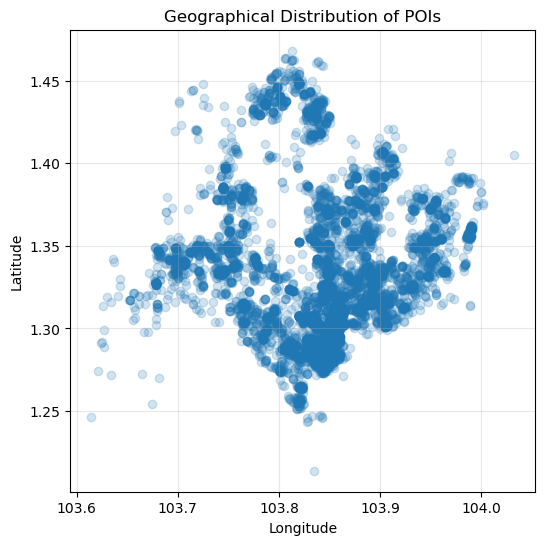

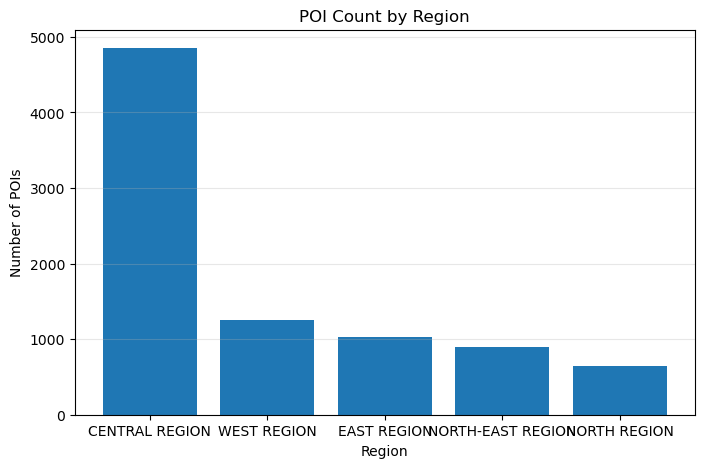

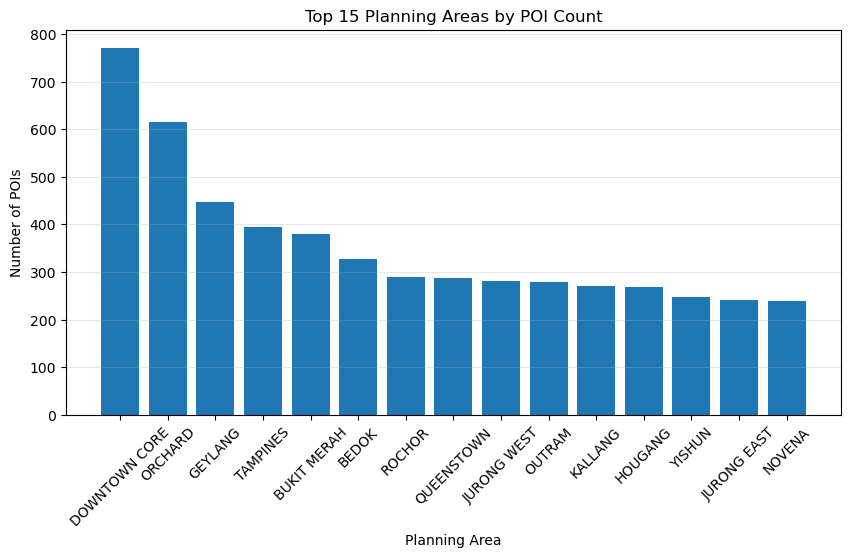

In [16]:
# Poi EDA

# Distribution of category groups
group_counts = poi[group_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(group_counts.index, group_counts.values)

plt.title("Distribution of POI Categories")
plt.xlabel("POI Category Group")
plt.ylabel("Number of POIs")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Average rating per POI category
category_rating = {}

for col in group_cols:
    category_rating[col] = poi[poi[col]]['rating'].mean()

category_rating = pd.Series(category_rating).sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_rating.index, category_rating.values)

plt.title("Average Rating by POI Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Geographical distribution of POIs
plt.figure(figsize=(6,6))
plt.scatter(poi['lng'], poi['lat'], alpha=0.2)

plt.title("Geographical Distribution of POIs")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.3)
plt.show()

# POI density by Region
region_counts = poi['REGION_N'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(region_counts.index, region_counts.values)

plt.title("POI Count by Region")
plt.xlabel("Region")
plt.ylabel("Number of POIs")

plt.grid(axis='y', alpha=0.3)
plt.show()

# POI density by Planning Area
area_counts = poi['PLN_AREA_N'].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(area_counts.index, area_counts.values)

plt.title("Top 15 Planning Areas by POI Count")
plt.xlabel("Planning Area")
plt.ylabel("Number of POIs")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# Feature Engineering

# Predict fair resale value for a HDB flat using
## Distance-Based Features (Distance from HDB to nearest bus stop, mrt station, POI)
## Density Features (Number of POIs, bus stops, mrt stations within a specified radius of the HDB)
## Transport Features (Number of operating days of the week for nearest bus stop, Busyness level of nearest bus stop)

# Stop-level operating days per week
bus_operating = bus_line.groupby('stop_id').agg({
    'WD_FirstBus': lambda x: x.notna().any(),
    'WD_LastBus':  lambda x: x.notna().any(),
    'SAT_FirstBus': lambda x: x.notna().any(),
    'SAT_LastBus':  lambda x: x.notna().any(),
    'SUN_FirstBus': lambda x: x.notna().any(),
    'SUN_LastBus':  lambda x: x.notna().any()
}).reset_index()

# Convert service availability into days/week
bus_operating['operates_weekday'] = bus_operating[['WD_FirstBus', 'WD_LastBus']].any(axis=1).astype(int)
bus_operating['operates_sat'] = bus_operating[['SAT_FirstBus', 'SAT_LastBus']].any(axis=1).astype(int)
bus_operating['operates_sun'] = bus_operating[['SUN_FirstBus', 'SUN_LastBus']].any(axis=1).astype(int)

bus_operating['operating_days_per_week'] = (
    bus_operating['operates_weekday'] * 5
    + bus_operating['operates_sat'] * 1
    + bus_operating['operates_sun'] * 1
)

bus_operating = bus_operating[['stop_id', 'operating_days_per_week']]

# 24 summary values per stop
# Average passenger volume for each stop-hour pair
bus_stop_hourly = (
    bus_vol.groupby(['stop_id', 'hour'], as_index=False)['total_volume']
    .mean()
    .rename(columns={'total_volume': 'avg_volume_at_hour'})
)

# One summary value per stop
# average passenger volume per hour across all hours (Basically how busy is the bus stop)
bus_hourly_summary = (
    bus_stop_hourly.groupby('stop_id', as_index=False)['avg_volume_at_hour']
    .mean()
    .rename(columns={'avg_volume_at_hour': 'avg_passenger_volume_per_hour'})
)

# Merge stop-level features
bus_stop_features = bus_stops.merge(bus_operating, on='stop_id', how='left')
bus_stop_features = bus_stop_features.merge(bus_hourly_summary, on='stop_id', how='left')

hdb_coords = hdb[['lat','lng']].copy()
mrt_coords = mrt[['lat','lng']].copy()
poi_coords = poi[['lat','lng']].copy()
bus_coords = bus_stop_features[['lat','lng']].copy()

# Convert to radians
def to_rad(df):
    return np.radians(df[['lat','lng']].values)

hdb_rad = to_rad(hdb_coords)
mrt_rad = to_rad(mrt_coords)
bus_rad = to_rad(bus_coords)
poi_rad = to_rad(poi_coords)

# Build trees
mrt_tree = BallTree(mrt_rad, metric='haversine')
bus_tree = BallTree(bus_rad, metric='haversine')
poi_tree = BallTree(poi_rad, metric='haversine')

# Distance to nearest MRT in meters
dist, _ = mrt_tree.query(hdb_rad, k=1)
hdb['dist_to_nearest_mrt_station'] = dist * 6371000  

# Distance to nearest bus stop in meters
dist, idx = bus_tree.query(hdb_rad, k=1)
hdb['dist_to_nearest_bus_stop'] = dist * 6371000  

# Distance to nearest POI in meters
dist, _ = poi_tree.query(hdb_rad, k=1)
hdb['dist_to_nearest_poi'] = dist * 6371000

radius = 500 / 6371000

# MRT Density
counts = mrt_tree.query_radius(hdb_rad, r=radius, count_only=True)
hdb['mrt_count_500m'] = counts

# Bus Stop Density
counts = bus_tree.query_radius(hdb_rad, r=radius, count_only=True)
hdb['bus_count_500m'] = counts

# POI Density
counts = poi_tree.query_radius(hdb_rad, r=radius, count_only=True)
hdb['poi_count_500m'] = counts

nearest_idx = idx.flatten()

# Number of operating days in a week for nearest bus stop
hdb['nearest_bus_stop_operating_days_per_week'] = (
    bus_stop_features.iloc[nearest_idx]['operating_days_per_week'].values
)

# Overall busyness of stop
hdb['nearest_bus_stop_busyness_level'] = (
    bus_stop_features.iloc[nearest_idx]['avg_passenger_volume_per_hour'].values
)

hdb = hdb.dropna()
hdb

,blk_no,street,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,...,REGION_C,building_age,dist_to_nearest_mrt_station,dist_to_nearest_bus_stop,dist_to_nearest_poi,mrt_count_500m,bus_count_500m,poi_count_500m,nearest_bus_stop_operating_days_per_week,nearest_bus_stop_busyness_level
0,1,BEACH RD,16,1970,Y,Y,N,N,N,N,...,CR,56,253.899860,64.314063,34.633527,3,24,218,7,1109.491667
1,1,BEDOK STH AVE 1,14,1975,Y,N,N,Y,N,N,...,ER,51,541.763839,197.853693,102.934013,0,9,21,7,1856.976190
3,1,CHAI CHEE RD,15,1982,Y,N,N,N,N,N,...,ER,44,919.036601,44.025162,213.355412,0,17,14,7,1045.730159
4,1,CHANGI VILLAGE RD,4,1975,Y,Y,N,N,N,N,...,ER,51,3480.030692,91.223908,73.484174,0,9,11,7,570.126984
5,1,DELTA AVE,25,1982,Y,N,N,N,N,N,...,CR,44,676.767335,163.453995,143.709514,0,14,52,7,1109.783333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12434,997C,BUANGKOK CRES,16,2017,Y,N,N,N,N,N,...,NER,9,635.663221,193.618775,135.622075,0,6,14,7,1828.641667
12437,998A,BUANGKOK CRES,18,2018,Y,N,N,N,N,N,...,NER,8,885.387907,66.408701,152.721362,0,10,16,7,1828.641667
12438,998B,BUANGKOK CRES,17,2018,Y,N,N,N,N,N,...,NER,8,832.304838,23.539913,165.814440,0,10,16,7,1828.641667
12440,999A,BUANGKOK CRES,18,2018,Y,N,N,N,N,N,...,NER,8,787.005654,98.818304,185.503822,0,8,15,7,1828.641667
